# Auto Regression

自回归是一种时间序列模型，它使用前一个时间步骤的观测值作为回归方程的输入来预测下一个时间步骤的值。

我们从与上一个教程中相同的模型开始。

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)



Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\pytorch_lightning\utilities\data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\pytorch_lightning\utilities\data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 22. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

Finding best initial lr: 100%|██████████| 229/229 [00:02<00:00, 103.69it/s]


Training: |          | 0/? [00:35<?, ?it/s, v_num=45, train_loss=0.014, reg_loss=0.000, MAE=4.830, RMSE=6.420, Loss=0.0139, RegLoss=0.000] 

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARN


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 222.78it/s]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()



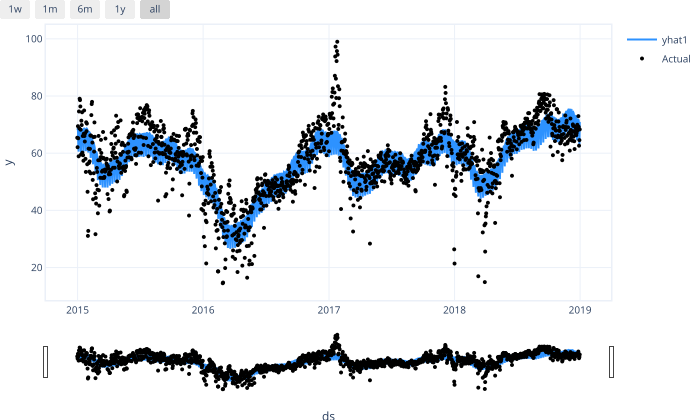

In [3]:
import pandas as pd
from neuralprophet import NeuralProphet, set_log_level

# Disable logging messages unless there is an error
set_log_level("ERROR")

# Load the dataset from the CSV file using pandas
df = pd.read_csv('./data/SF_hospital_load.csv')

# Model and prediction
m = NeuralProphet(
    n_changepoints=10,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
)
m.set_plotting_backend("plotly-static")
metrics = m.fit(df)
forecast = m.predict(df)
m.plot(forecast)

为了更好地理解我们的模型与实际数据之间剩余的不匹配是什么，我们可以看看残差。残差是模型预测与实际数据之间的差异。如果模型完美，残差应该为零。

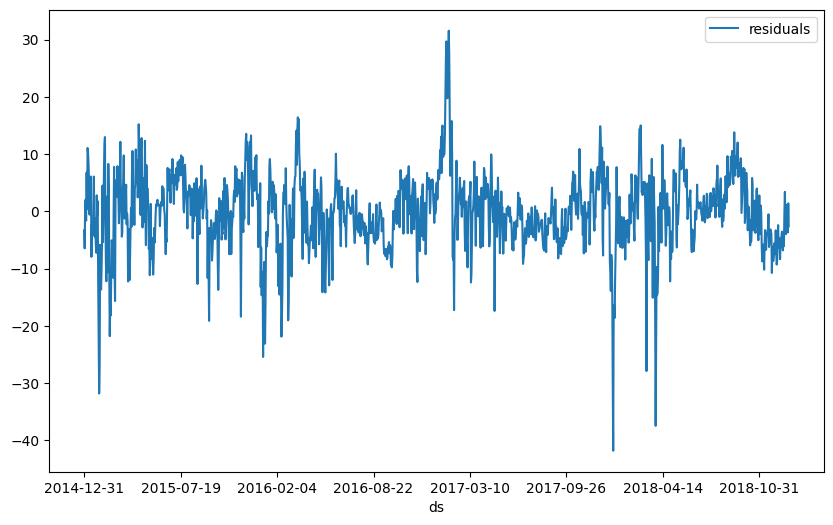

In [4]:
df_residuals = pd.DataFrame({"ds": df["ds"], "residuals": df["y"] - forecast["yhat1"]})
fig = df_residuals.plot(x="ds", y="residuals", figsize=(10, 6))

让我们探索一下自回归的良好值是多少。创建一个自相关图。

无自相关（白噪声）：如果你的残差没有显著的自相关性，说明模型已经捕捉到了数据中的大部分模式，残差已经近似随机。在这种情况下，通常不需要增加额外的自回归（AR）项。你可以选择 autoregression=0 或者 不启用自回归。

显著的自相关：如果在 ACF 图中看到残差存在显著的自相关（例如，某些滞后期有较高的自相关值），说明你的模型尚未完全捕捉到数据中的某些模式，可能需要引入自回归项来增强模型的预测能力。你可以根据 ACF 图选择适当的滞后期数，并设置 autoregression 参数。

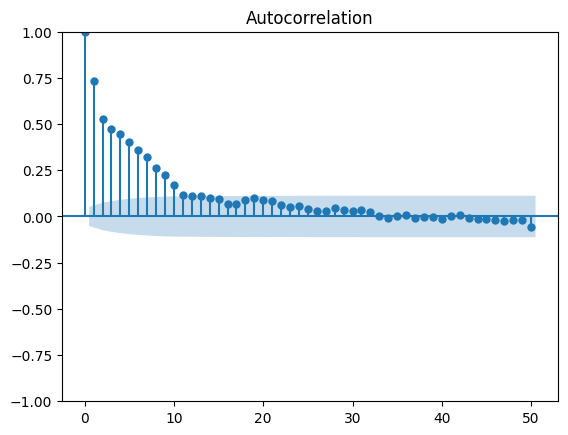

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

plt = plot_acf(df_residuals["residuals"], lags=50)

可以看到当选择n_lag = 10 时，可以额囊括自相关系数较高的几个滞后期。如果 ACF 图在前几个滞后期有显著的峰值，可能需要增加自回归的阶数。比如，如果 ACF 在滞后1和2时有高自相关，选择 autoregression=2 或更高的值可能会有所帮助。

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.




Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\pytorch_lightning\utilities\data.py:78: UserWarning:

Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 12. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Finding best initial lr: 100%|██████████| 229/229 [00:02<00:00, 111.68it/s]


Training: |          | 0/? [00:39<?, ?it/s, v_num=46, train_loss=0.00628, reg_loss=0.000, MAE=3.170, RMSE=4.310, Loss=0.00624, RegLoss=0.000]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use 


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 154.27it/s]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_matplotlib.py:84: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




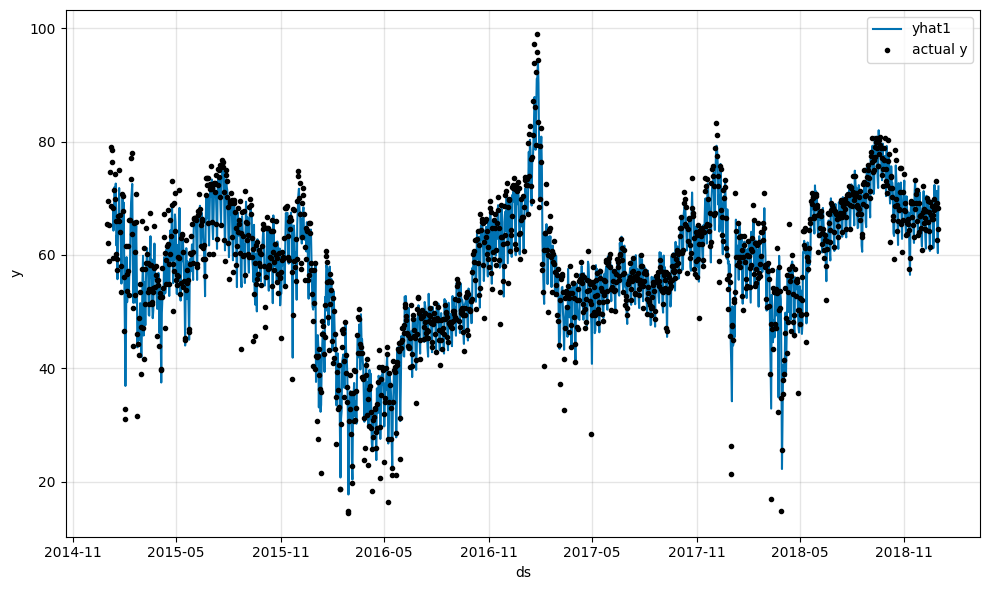

In [6]:
# Model and prediction
m = NeuralProphet(
    # Disable trend changepoints
    n_changepoints=10,
    # Disable seasonality components
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    # Add the autogression
    n_lags=10,
)
m.set_plotting_backend("matplotlib")  # Use matplotlib due to #1235
metrics = m.fit(df)
forecast = m.predict(df)
m.plot(forecast)

我们可以看到，自回归预测模型确实比基础模型更能拟合数据。请随意探索不同滞后数 n_lags 对模型的影响。

In [7]:
metrics

,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss,epoch
0,0.790709,0.0,72.424767,85.569702,0.787508,0.0,0
1,0.435693,0.0,43.542515,52.633698,0.435515,0.0,1
2,0.272039,0.0,29.653095,37.311699,0.272493,0.0,2
3,0.174171,0.0,21.095871,26.986649,0.173957,0.0,3
4,0.101719,0.0,14.523854,18.970806,0.101222,0.0,4
...,...,...,...,...,...,...,...
95,0.006286,0.0,3.210130,4.345917,0.006393,0.0,95
96,0.006287,0.0,3.185480,4.309728,0.006284,0.0,96
97,0.006286,0.0,3.162371,4.277816,0.006226,0.0,97
98,0.006283,0.0,3.179889,4.306146,0.006254,0.0,98


In [9]:
import pandas as pd
from neuralprophet import NeuralProphet, set_log_level
from sklearn.metrics import mean_absolute_percentage_error

# Model and prediction
m = NeuralProphet(
    # Disable trend changepoints
    n_changepoints=10,
    # Disable seasonality components
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    # Add the autogression
    n_lags=10,
)

ts_train, ts_test = m.split_df(df, valid_p = 0.2, local_split = True)
metrics = m.fit(ts_train)
forecast_test = m.predict(ts_test)
last_day = 60
m.plot(forecast_test)



WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.




WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.




Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 227/227 [00:02<00:00, 103.83it/s]


Training: |          | 0/? [00:35<?, ?it/s, v_num=48, train_loss=0.00907, reg_loss=0.000, MAE=3.820, RMSE=5.070, Loss=0.00929, RegLoss=0.000]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use 


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 167.14it/s]

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




In [10]:
print(f'mean_absolute_percentage_error for last {last_day} days is:')
print(mean_absolute_percentage_error(df.set_index('ds')['y'].iloc[-last_day:], forecast_test.set_index('ds')['yhat1'].iloc[-last_day:]))

mean_absolute_percentage_error for last 60 days is:
0.03574444710575839
